# Mini Project 1 – Advanced Classification Pipeline

In [10]:
# ==========================================================
# Mini Project 1 – Advanced Classification Pipeline
# Dataset: IBM HR Employee Attrition
# ชื่อ-นามสกุล: จิราพร ใจยสุข
# รหัสนักศึกษา: 6609520090
# แหล่งอ้างอิงข้อมูล: https://raw.githubusercontent.com/Jiraporn-Jaiyasuk/ML-MiniProject-Attrition/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# 1) LOAD DATA

In [11]:
# ==========================================================
# 1) LOAD DATA
# ==========================================================

url = "https://raw.githubusercontent.com/Jiraporn-Jaiyasuk/ML-MiniProject-Attrition/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)

print("===== BEFORE CLEANING =====")
print("Shape:", df.shape)
print("Class distribution:")
print(df["Attrition"].value_counts(normalize=True))

===== BEFORE CLEANING =====
Shape: (1470, 35)
Class distribution:
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


# 2) DATA CLEANING

In [12]:
# ==========================================================
# 2) DATA CLEANING
# ==========================================================

# Remove constant columns
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print("Constant columns:", constant_cols)

df = df.drop(columns=constant_cols + ["EmployeeNumber"])

# Check missing
print("Missing values:", df.isnull().sum().sum())

# Encode target
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# One-hot encoding
df_encoded = pd.get_dummies(df)

print("===== AFTER ENCODING =====")
print("Shape:", df_encoded.shape)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Missing values: 0
===== AFTER ENCODING =====
Shape: (1470, 52)


# 3) SPLIT DATA

In [13]:
# ==========================================================
# 3) SPLIT DATA
# ==========================================================

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

X_dev, X_eval, y_dev, y_eval = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4) SCALING (Before vs After Visualization)

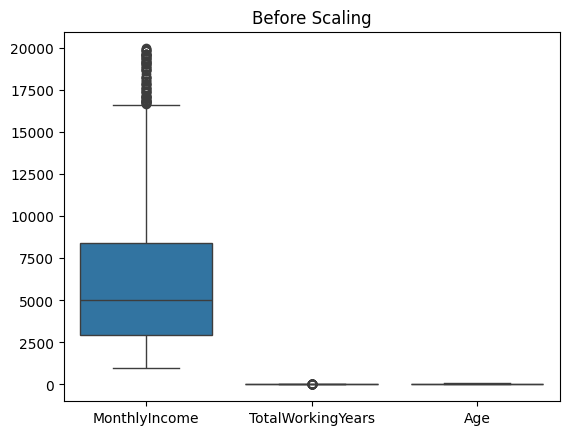

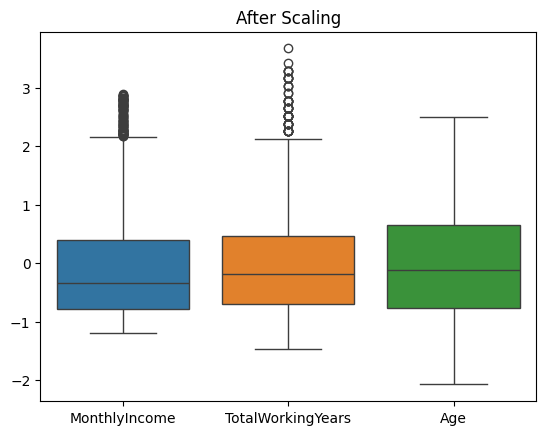

In [14]:
# ==========================================================
# 4) SCALING (Before vs After Visualization)
# ==========================================================

numeric_cols = ["MonthlyIncome", "TotalWorkingYears", "Age"]

plt.figure()
sns.boxplot(data=X_dev[numeric_cols])
plt.title("Before Scaling")
plt.show()

scaler = StandardScaler()
X_dev_scaled = scaler.fit_transform(X_dev)
X_eval_scaled = scaler.transform(X_eval)

X_dev_scaled_df = pd.DataFrame(X_dev_scaled, columns=X.columns)

plt.figure()
sns.boxplot(data=X_dev_scaled_df[numeric_cols])
plt.title("After Scaling")
plt.show()

# 5) FEATURE IMPORTANCE (Tree-based + Permutation)

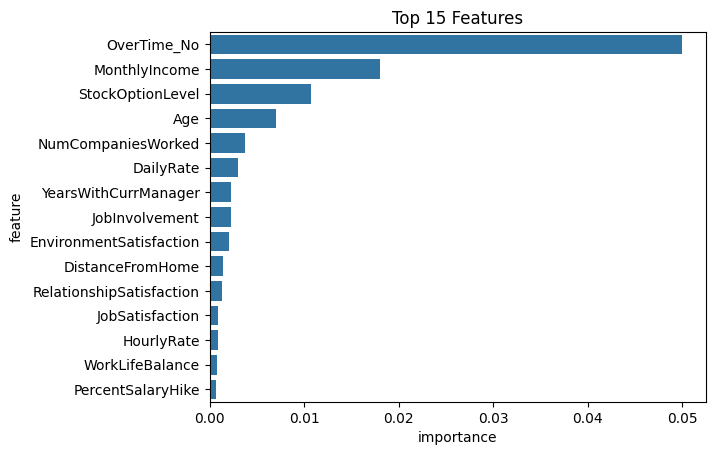

Top 3 Features:
             feature  importance
49       OverTime_No    0.050000
9      MonthlyIncome    0.018027
15  StockOptionLevel    0.010714


In [15]:
# ==========================================================
# 5) FEATURE IMPORTANCE (Tree-based + Permutation)
# ==========================================================

scale_pos_weight = y_dev.value_counts()[0] / y_dev.value_counts()[1]

xgb_fs = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_fs.fit(X_dev_scaled, y_dev)

perm = permutation_importance(
    xgb_fs, X_dev_scaled, y_dev,
    n_repeats=10, random_state=42
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

# Plot Top 15
plt.figure()
sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(15)
)
plt.title("Top 15 Features")
plt.show()

top3 = importance_df.head(3)
print("Top 3 Features:")
print(top3)

# 6) OPTIMAL FEATURE COUNT

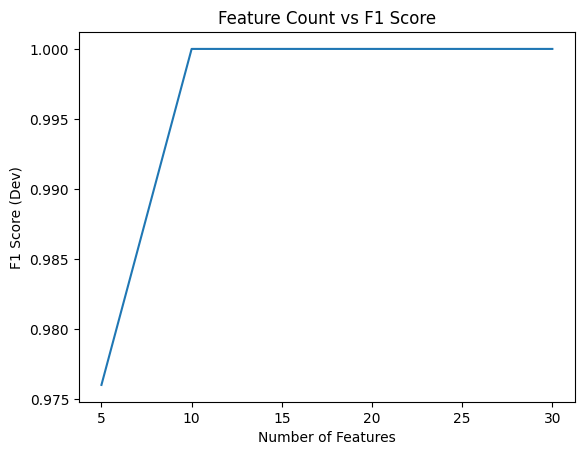

In [16]:
# ==========================================================
# 6) OPTIMAL FEATURE COUNT
# ==========================================================

f1_scores = []
feature_counts = range(5, 31, 5)

for k in feature_counts:
    selected = importance_df.head(k)["feature"]
    X_dev_sel = X_dev_scaled_df[selected]
    model = XGBClassifier(random_state=42)
    model.fit(X_dev_sel, y_dev)
    pred = model.predict(X_dev_sel)
    f1_scores.append(f1_score(y_dev, pred))

plt.figure()
plt.plot(feature_counts, f1_scores)
plt.xlabel("Number of Features")
plt.ylabel("F1 Score (Dev)")
plt.title("Feature Count vs F1 Score")
plt.show()

# Select Top 15
selected_features = importance_df.head(15)["feature"]

X_dev_sel = X_dev_scaled_df[selected_features]
X_eval_sel = pd.DataFrame(
    X_eval_scaled,
    columns=X.columns
)[selected_features]

# 7) MODEL TRAINING

In [17]:
# ==========================================================
# 7) MODEL TRAINING
# ==========================================================

# kNN
knn = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": [3, 5, 7]},
    cv=5, scoring="f1"
)
knn.fit(X_dev_sel, y_dev)

# XGBoost
xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    {"n_estimators": [100, 200]},
    cv=5, scoring="f1"
)
xgb.fit(X_dev_sel, y_dev)

# Neural Network
nn = GridSearchCV(
    MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ),
    {
        "hidden_layer_sizes": [(50,), (100,)],
        "alpha": [0.001, 0.01]
    },
    cv=5, scoring="f1"
)
nn.fit(X_dev_sel, y_dev)

GridSearchCV(cv=5,
             estimator=MLPClassifier(early_stopping=True, max_iter=1000,
                                     random_state=42),
             param_grid={'alpha': [0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,)]},
             scoring='f1')

# 8) EVALUATION


===== kNN =====
Best Params: {'n_neighbors': 3}
CV F1: 0.2820928930102645
Eval F1: 0.208955223880597
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       247
           1       0.35      0.15      0.21        47

    accuracy                           0.82       294
   macro avg       0.60      0.55      0.55       294
weighted avg       0.77      0.82      0.79       294



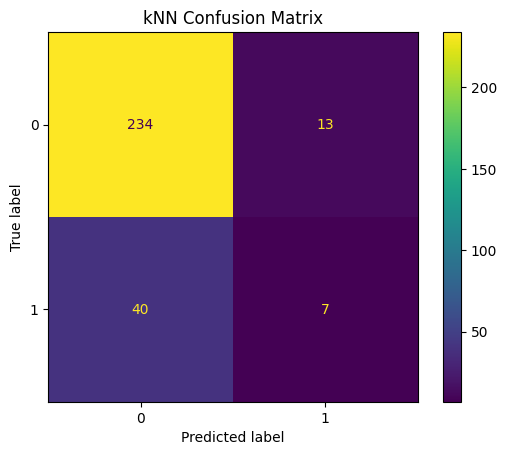

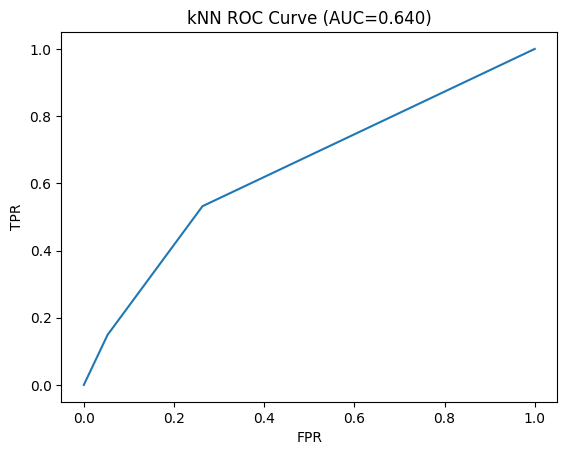


===== XGBoost =====
Best Params: {'n_estimators': 200}
CV F1: 0.41811920560158605
Eval F1: 0.358974358974359
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.45      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.63       294
weighted avg       0.81      0.83      0.82       294



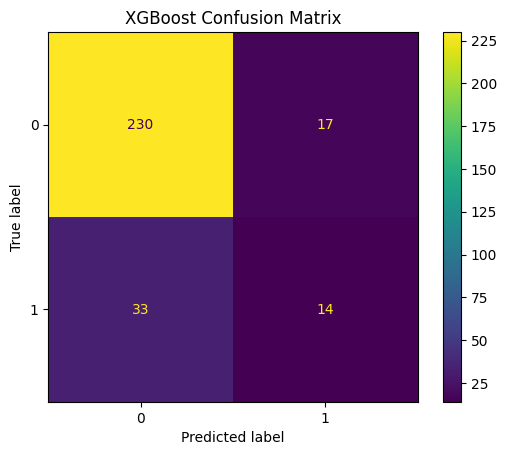

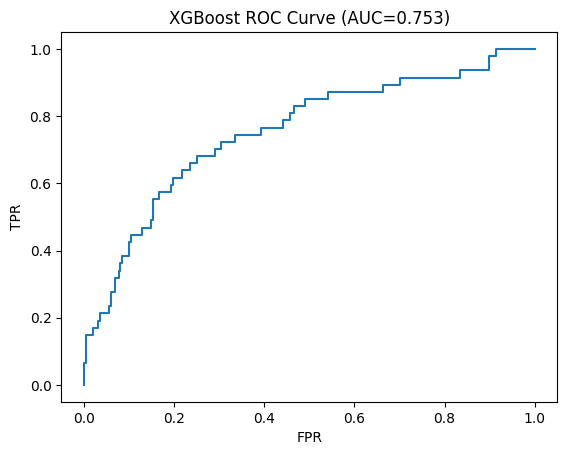


===== NeuralNet =====
Best Params: {'alpha': 0.01, 'hidden_layer_sizes': (100,)}
CV F1: 0.10965005302226935
Eval F1: 0.12
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       247
           1       1.00      0.06      0.12        47

    accuracy                           0.85       294
   macro avg       0.92      0.53      0.52       294
weighted avg       0.87      0.85      0.79       294



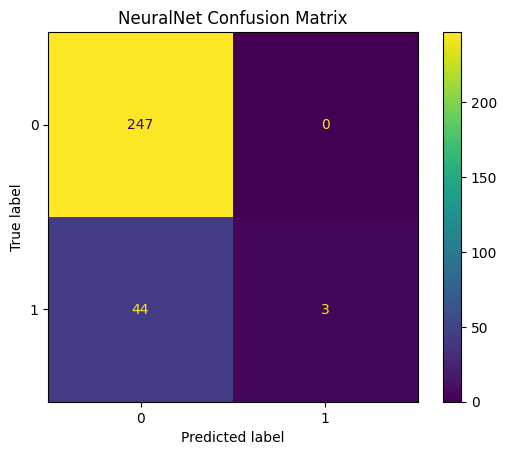

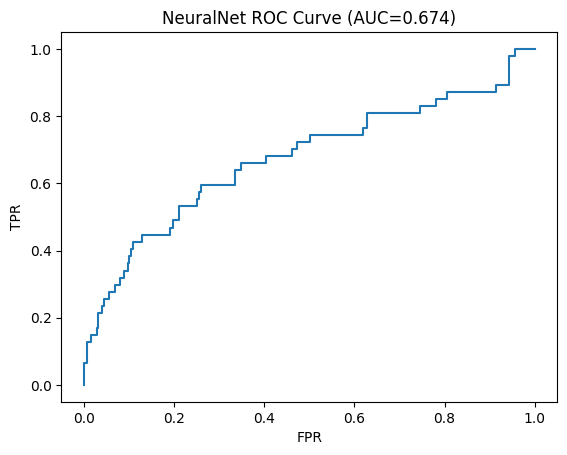

In [18]:
# ==========================================================
# 8) EVALUATION
# ==========================================================

models = {
    "kNN": knn,
    "XGBoost": xgb,
    "NeuralNet": nn
}

for name, model in models.items():
    print(f"\n===== {name} =====")
    print("Best Params:", model.best_params_)
    print("CV F1:", model.best_score_)

    y_pred = model.predict(X_eval_sel)
    print("Eval F1:", f1_score(y_eval, y_pred))
    print(classification_report(y_eval, y_pred))

    cm = confusion_matrix(y_eval, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_eval, model.predict_proba(X_eval_sel)[:,1])
    plt.plot(fpr, tpr)
    plt.title(f"{name} ROC Curve (AUC={auc(fpr,tpr):.3f})")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()